### Task 1: Environment Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

np.random.seed(42)

In [2]:
# Create the FrozenLake-v1 environment.
# map_name="4x4" creates the standard 4 by 4 grid.
# is_slippery=False makes the environment deterministic, so actions behave as expected.
# render_mode="ansi" allows the environment to be rendered as text.
frozen_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="ansi"
)

# Print the observation space.
# FrozenLake has 16 states because the grid contains 4 x 4 = 16 tiles.
print("FrozenLake Observation Space:", frozen_env.observation_space)

# Print the action space.
# FrozenLake has 4 possible actions.
print("FrozenLake Action Space:", frozen_env.action_space)

# Explain the meaning of each action index.
print("\nFrozenLake action meanings:")
print("0 = Move left")
print("1 = Move down")
print("2 = Move right")
print("3 = Move up")

FrozenLake Observation Space: Discrete(16)
FrozenLake Action Space: Discrete(4)

FrozenLake action meanings:
0 = Move left
1 = Move down
2 = Move right
3 = Move up


In [3]:
# Reset the environment to the initial state.
state, info = frozen_env.reset(seed=42)

# Render and print the FrozenLake grid.
print("FrozenLake Grid:")
print(frozen_env.render())

FrozenLake Grid:

SFFF
FHFH
FFFH
HFFG



In [4]:
# Run 5 episodes using random actions.
for episode in range(1, 6):
    # Reset the environment at the beginning of each episode.
    state, info = frozen_env.reset(seed=42 + episode)

    # Initialize episode variables.
    done = False
    total_reward = 0
    steps = 0

    # Continue the episode until the agent reaches a terminal state.
    while not done:
        # Select a random action from the action space.
        action = frozen_env.action_space.sample()

        # Apply the selected action to the environment.
        next_state, reward, terminated, truncated, info = frozen_env.step(action)

        # The episode ends if it is terminated or truncated.
        done = terminated or truncated

        # Update the total reward and step counter.
        total_reward += reward
        steps += 1

        # Move to the next state.
        state = next_state

    # Print the result of the episode.
    print(f"FrozenLake Episode {episode}: Total Reward = {total_reward}, Steps = {steps}")

FrozenLake Episode 1: Total Reward = 0, Steps = 6
FrozenLake Episode 2: Total Reward = 0, Steps = 3
FrozenLake Episode 3: Total Reward = 0, Steps = 7
FrozenLake Episode 4: Total Reward = 0, Steps = 4
FrozenLake Episode 5: Total Reward = 0, Steps = 2


In [5]:
# Create the Taxi-v4 environment.
# Taxi-v3 is deprecated in the installed Gymnasium version, so Taxi-v4 is used instead.
taxi_env = gym.make("Taxi-v4")

# Print the observation space.
# Taxi has 500 possible states.
print("Taxi Observation Space:", taxi_env.observation_space)

# Print the action space.
# Taxi has 6 possible actions.
print("Taxi Action Space:", taxi_env.action_space)

# Explain the meaning of each Taxi action index.
print("\nTaxi action meanings:")
print("0 = Move south")
print("1 = Move north")
print("2 = Move east")
print("3 = Move west")
print("4 = Pick up passenger")
print("5 = Drop off passenger")

Taxi Observation Space: Discrete(500)
Taxi Action Space: Discrete(6)

Taxi action meanings:
0 = Move south
1 = Move north
2 = Move east
3 = Move west
4 = Pick up passenger
5 = Drop off passenger


In [6]:
# Run 5 episodes using random actions.
for episode in range(1, 6):
    # Reset the environment at the beginning of each episode.
    state, info = taxi_env.reset(seed=42)

    # Initialize episode variables.
    done = False
    total_reward = 0
    steps = 0

    # Continue the episode until it ends.
    while not done:
        # Select a random action from the Taxi action space.
        action = taxi_env.action_space.sample()

        # Apply the selected action to the environment.
        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        # The episode ends if it is terminated or truncated.
        done = terminated or truncated

        # Update the total reward and step counter.
        total_reward += reward
        steps += 1

        # Move to the next state.
        state = next_state

    # Print the result of the episode.
    print(f"Taxi Episode {episode}: Total Reward = {total_reward}, Steps = {steps}")

Taxi Episode 1: Total Reward = -436, Steps = 133
Taxi Episode 2: Total Reward = -495, Steps = 147
Taxi Episode 3: Total Reward = -794, Steps = 200
Taxi Episode 4: Total Reward = -695, Steps = 200
Taxi Episode 5: Total Reward = -713, Steps = 200


## Task 1 Interpretation

In this task, I explored the FrozenLake and Taxi reinforcement learning environments using random actions.

FrozenLake has 16 states and 4 actions because it is a 4×4 grid. The action space represents four possible movements: left, down, right, and up. The rendered grid shows the structure of the environment, where `S` is the start position, `F` represents safe frozen tiles, `H` represents holes, and `G` is the goal. During the 5 random episodes, the agent received a total reward of 0 every time. This is expected because the random agent does not know the safe path to the goal and can easily fall into a hole or stop without reaching the goal.

Taxi is more complex than FrozenLake. It has 500 states and 6 actions. In addition to movement actions, the agent must also learn when to pick up and drop off the passenger. The random Taxi agent received negative rewards in all 5 episodes. Some episodes ended before the step limit, while others reached 200 steps. This shows that random behavior is inefficient in Taxi because the agent often moves without a useful strategy and may attempt incorrect pickup or drop-off actions.

Overall, Taxi is harder than FrozenLake because it has a much larger state space, more available actions, and a longer goal sequence. FrozenLake only requires reaching the goal safely, while Taxi requires navigating to the passenger, picking them up, navigating to the correct destination, and dropping them off successfully.

### Task 2: Q-Learning on FrozenLake

In [7]:
# Create the FrozenLake-v1 environment again for Q-Learning.
# The environment is deterministic because is_slippery=False.
frozen_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="ansi"
)

# Get the number of states and actions from the environment.
n_states = frozen_env.observation_space.n
n_actions = frozen_env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [8]:
# Initialize the Q-table with zeros.
# Rows represent states, and columns represent actions.
q_table_frozen = np.zeros((n_states, n_actions))

# Set Q-Learning hyperparameters.
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes = 10000

# Create a list to store the reward from each episode.
frozen_rewards = []

print("Initial Q-table shape:", q_table_frozen.shape)
print(q_table_frozen)

Initial Q-table shape: (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [9]:
# Train the Q-Learning agent for 10,000 episodes.
for episode in range(num_episodes):
    # Reset the environment at the beginning of each episode.
    state, info = frozen_env.reset(seed=42)

    # Initialize episode variables.
    done = False
    total_reward = 0

    # Continue until the episode ends.
    while not done:
        # Use epsilon-greedy action selection.
        # With probability epsilon, the agent explores by choosing a random action.
        # Otherwise, it exploits by choosing the action with the highest Q-value.
        if np.random.random() < epsilon:
            action = frozen_env.action_space.sample()
        else:
            action = np.argmax(q_table_frozen[state])

        # Apply the selected action to the environment.
        next_state, reward, terminated, truncated, info = frozen_env.step(action)

        # Check if the episode has ended.
        done = terminated or truncated

        # Update the Q-value using the Q-Learning update rule.
        q_table_frozen[state, action] = q_table_frozen[state, action] + alpha * (
            reward + gamma * np.max(q_table_frozen[next_state]) - q_table_frozen[state, action]
        )

        # Move to the next state.
        state = next_state

        # Add the reward to the episode total.
        total_reward += reward

    # Store the total reward for this episode.
    frozen_rewards.append(total_reward)

    # Decay epsilon after each episode.
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training completed.")
print("Final epsilon:", epsilon)

Training completed.
Final epsilon: 0.01


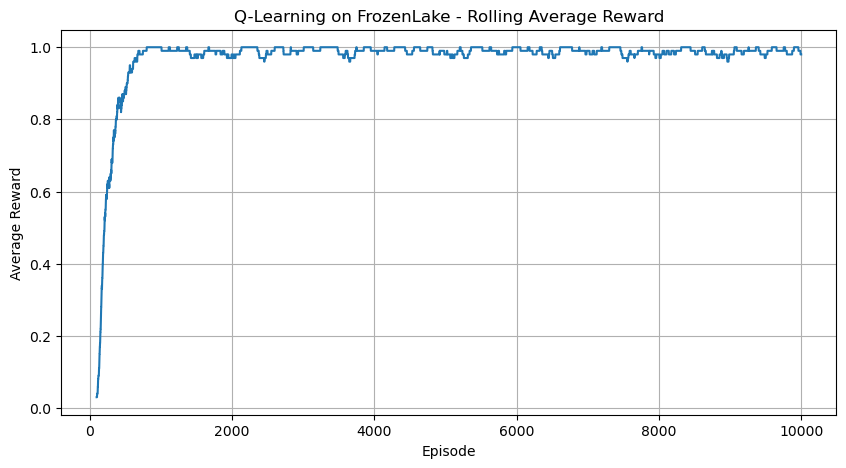

In [10]:
# Convert the rewards list into a pandas Series.
frozen_rewards_series = pd.Series(frozen_rewards)

# Calculate the rolling average with a window size of 100 episodes.
rolling_average_frozen = frozen_rewards_series.rolling(window=100).mean()

# Plot the rolling average reward.
plt.figure(figsize=(10, 5))
plt.plot(rolling_average_frozen)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning on FrozenLake - Rolling Average Reward")
plt.grid(True)
plt.show()

In [11]:
# Print the final learned Q-table.
print("Final Q-table for FrozenLake:")
print(q_table_frozen)

Final Q-table for FrozenLake:
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.64635463 0.69264318]
 [0.69699245 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.722      0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.82308    0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


In [12]:
# Find the best action from the start state.
start_state = 0
best_action_start = np.argmax(q_table_frozen[start_state])

print("Q-values for start state:", q_table_frozen[start_state])
print("Best action from start state:", best_action_start)

if best_action_start == 0:
    print("Best action meaning: Move left")
elif best_action_start == 1:
    print("Best action meaning: Move down")
elif best_action_start == 2:
    print("Best action meaning: Move right")
elif best_action_start == 3:
    print("Best action meaning: Move up")

Q-values for start state: [0.73509189 0.77378094 0.6983373  0.73509189]
Best action from start state: 1
Best action meaning: Move down


In [13]:
# Define symbols for each action to make the learned policy easier to read.
action_symbols = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

# Create the learned policy by selecting the best action in each state.
policy = np.array([action_symbols[np.argmax(q_table_frozen[state])] for state in range(n_states)])

# Reshape the policy into the 4x4 FrozenLake grid.
policy_grid = policy.reshape(4, 4)

print("Learned policy:")
print(policy_grid)

Learned policy:
[['↓' '←' '←' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]


## Task 2 Interpretation

In this task, I implemented Q-Learning from scratch on the deterministic FrozenLake environment.

The environment has 16 states and 4 actions, so the Q-table was initialized with the shape `(16, 4)`. At the beginning, all values in the Q-table were zero because the agent had not learned which actions were useful yet. During training, these values were updated based on the reward received and the best estimated future reward.

The agent was trained for 10,000 episodes. Epsilon started at 1.0, so the agent explored randomly at the beginning. After training, epsilon decayed to 0.01, meaning the agent mostly used the learned Q-values while still keeping a small amount of exploration.

The rolling average reward increased quickly and became stable close to 1.0. This shows that the agent learned a successful path to the goal after the early exploration phase. The final Q-table contains higher values for actions that lead toward the goal, while terminal states and less useful actions have lower or zero values.

For the start state, the highest Q-value was for action `1`, which means moving down. This makes sense because moving down is part of a safe route in the deterministic FrozenLake map. The learned policy also shows that the agent learned to move through safe tiles toward the goal while avoiding holes.

### Task 3: Q-Learning on Taxi

In [14]:
# Create the Taxi environment.
# Taxi-v4 is used because Taxi-v3 is deprecated in this Gymnasium version.
taxi_env = gym.make("Taxi-v4")

# Get the number of states and actions.
n_states_taxi = taxi_env.observation_space.n
n_actions_taxi = taxi_env.action_space.n

print("Number of Taxi states:", n_states_taxi)
print("Number of Taxi actions:", n_actions_taxi)

Number of Taxi states: 500
Number of Taxi actions: 6


In [15]:
# Initialize the Q-table with zeros for the Taxi environment.
q_table_taxi = np.zeros((n_states_taxi, n_actions_taxi))

# Use the same hyperparameters as Task 2.
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes = 20000

# Store the reward from each episode.
taxi_rewards = []

print("Initial Taxi Q-table shape:", q_table_taxi.shape)

Initial Taxi Q-table shape: (500, 6)


In [16]:
# Train the Q-Learning agent on Taxi for 20,000 episodes.
for episode in range(num_episodes):
    # Reset the environment at the beginning of each episode.
    state, info = taxi_env.reset(seed=42)

    # Initialize episode variables.
    done = False
    total_reward = 0

    # Continue until the episode ends.
    while not done:
        # Use epsilon-greedy action selection.
        # With probability epsilon, choose a random action.
        # Otherwise, choose the action with the highest Q-value.
        if np.random.random() < epsilon:
            action = taxi_env.action_space.sample()
        else:
            action = np.argmax(q_table_taxi[state])

        # Apply the selected action to the environment.
        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        # The episode ends if it is terminated or truncated.
        done = terminated or truncated

        # Update the Q-value using the Q-Learning update rule.
        q_table_taxi[state, action] = q_table_taxi[state, action] + alpha * (
            reward + gamma * np.max(q_table_taxi[next_state]) - q_table_taxi[state, action]
        )

        # Move to the next state.
        state = next_state

        # Add the reward to the total episode reward.
        total_reward += reward

    # Store the total reward for this episode.
    taxi_rewards.append(total_reward)

    # Decay epsilon after each episode.
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Taxi Q-Learning training completed.")
print("Final epsilon:", epsilon)

Taxi Q-Learning training completed.
Final epsilon: 0.01


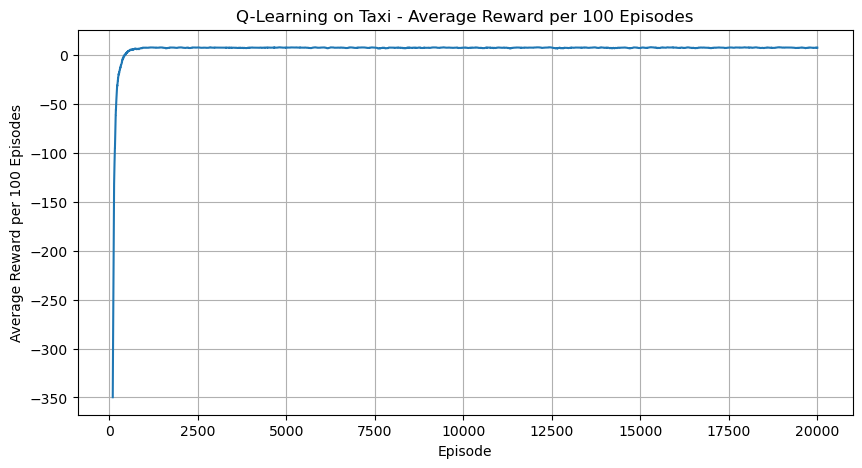

In [17]:
# Convert rewards to a pandas Series.
taxi_rewards_series = pd.Series(taxi_rewards)

# Calculate the average reward over every 100 episodes.
taxi_average_reward_100 = taxi_rewards_series.rolling(window=100).mean()

# Plot the smoothed training curve.
plt.figure(figsize=(10, 5))
plt.plot(taxi_average_reward_100)
plt.xlabel("Episode")
plt.ylabel("Average Reward per 100 Episodes")
plt.title("Q-Learning on Taxi - Average Reward per 100 Episodes")
plt.grid(True)
plt.show()

In [18]:
# Evaluate the trained Taxi agent using pure exploitation.
test_episodes = 100
test_rewards = []
successful_episodes = 0

for episode in range(test_episodes):
    # Reset the environment for each test episode.
    state, info = taxi_env.reset(seed=42)

    done = False
    total_reward = 0

    # Run the episode using only the best learned action.
    while not done:
        # Choose the action with the highest Q-value.
        action = np.argmax(q_table_taxi[state])

        # Apply the selected action.
        next_state, reward, terminated, truncated, info = taxi_env.step(action)

        # Check whether the episode has ended.
        done = terminated or truncated

        # Update total reward and state.
        total_reward += reward
        state = next_state

    # Store the test reward.
    test_rewards.append(total_reward)

    # Count the episode as successful if total reward is positive.
    if total_reward > 0:
        successful_episodes += 1

# Calculate evaluation metrics.
average_test_reward = np.mean(test_rewards)
success_rate = successful_episodes / test_episodes

print("Average reward over 100 test episodes:", average_test_reward)
print("Success rate:", success_rate)

Average reward over 100 test episodes: 8.0
Success rate: 1.0


In [19]:
# Create a Taxi environment with ansi rendering to display one trained episode.
taxi_render_env = gym.make("Taxi-v4", render_mode="ansi")

# Reset the render environment.
state, info = taxi_render_env.reset()

done = False
total_reward = 0
steps = 0

# Run one episode using the learned policy.
while not done:
    # Choose the best learned action.
    action = np.argmax(q_table_taxi[state])

    # Apply the action.
    next_state, reward, terminated, truncated, info = taxi_render_env.step(action)

    # Update episode variables.
    done = terminated or truncated
    total_reward += reward
    steps += 1
    state = next_state

print(taxi_render_env.render())
print("Total reward:", total_reward)
print("Steps:", steps)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Total reward: -200
Steps: 200


## Task 3 Interpretation

In this task, Q-Learning was applied to the Taxi environment. Taxi has 500 states and 6 actions, so the Q-table was initialized with the shape `(500, 6)`. This makes the problem larger and more complex than FrozenLake because the agent must learn movement, passenger pickup, and passenger drop-off behavior.

The Q-Learning agent was trained for 20,000 episodes. During training, epsilon decayed to 0.01, meaning the agent gradually changed from mostly exploring random actions to mostly exploiting the learned Q-values. The training curve shows that the average reward improved quickly from a large negative value and then became stable near a positive reward level. This indicates that the agent learned an effective policy.

In the evaluation phase, the trained agent achieved an average reward of 8.0 over 100 test episodes and a success rate of 1.0. This means the agent successfully completed the Taxi task in all test episodes when using the learned policy without exploration.

The single rendered episode shown above ended with a total reward of -200 after 200 steps, so it did not complete successfully. However, the 100-episode evaluation is a more reliable measurement than one rendered example, and it shows that the trained Q-Learning agent performs successfully overall.

### Task 4: SARSA Comparison

In [20]:
# Create the Taxi environment.
# Taxi-v4 is used because Taxi-v3 is deprecated in this Gymnasium version.
taxi_env_sarsa = gym.make("Taxi-v4")

# Get the number of states and actions.
n_states_sarsa = taxi_env_sarsa.observation_space.n
n_actions_sarsa = taxi_env_sarsa.action_space.n

print("Number of Taxi states:", n_states_sarsa)
print("Number of Taxi actions:", n_actions_sarsa)

Number of Taxi states: 500
Number of Taxi actions: 6


In [21]:
# Initialize the SARSA Q-table with zeros.
q_table_sarsa = np.zeros((n_states_sarsa, n_actions_sarsa))

# Use the same hyperparameters as Q-Learning.
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes = 20000

# Store the reward from each SARSA episode.
sarsa_rewards = []

print("Initial SARSA Q-table shape:", q_table_sarsa.shape)

Initial SARSA Q-table shape: (500, 6)


In [22]:
# Define an epsilon-greedy action selection function.
def choose_action_epsilon_greedy(q_table, state, env, epsilon):
    # With probability epsilon, choose a random action for exploration.
    if np.random.random() < epsilon:
        return env.action_space.sample()
    
    # Otherwise, choose the action with the highest Q-value for exploitation.
    return np.argmax(q_table[state])

In [23]:
# Train the SARSA agent on Taxi for 20,000 episodes.
for episode in range(num_episodes):
    # Reset the environment at the beginning of each episode.
    state, info = taxi_env_sarsa.reset(seed=42)

    # Choose the first action using the current epsilon-greedy policy.
    action = choose_action_epsilon_greedy(q_table_sarsa, state, taxi_env_sarsa, epsilon)

    # Initialize episode variables.
    done = False
    total_reward = 0

    # Continue until the episode ends.
    while not done:
        # Apply the selected action to the environment.
        next_state, reward, terminated, truncated, info = taxi_env_sarsa.step(action)

        # The episode ends if it is terminated or truncated.
        done = terminated or truncated

        # Choose the next action using the same epsilon-greedy policy.
        next_action = choose_action_epsilon_greedy(q_table_sarsa, next_state, taxi_env_sarsa, epsilon)

        # Update the Q-value using the SARSA update rule.
        # SARSA uses the Q-value of the actual next action, not the maximum next Q-value.
        q_table_sarsa[state, action] = q_table_sarsa[state, action] + alpha * (
            reward + gamma * q_table_sarsa[next_state, next_action] - q_table_sarsa[state, action]
        )

        # Move to the next state and next action.
        state = next_state
        action = next_action

        # Add the reward to the total episode reward.
        total_reward += reward

    # Store the total reward for this episode.
    sarsa_rewards.append(total_reward)

    # Decay epsilon after each episode.
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("SARSA training completed.")
print("Final epsilon:", epsilon)

SARSA training completed.
Final epsilon: 0.01


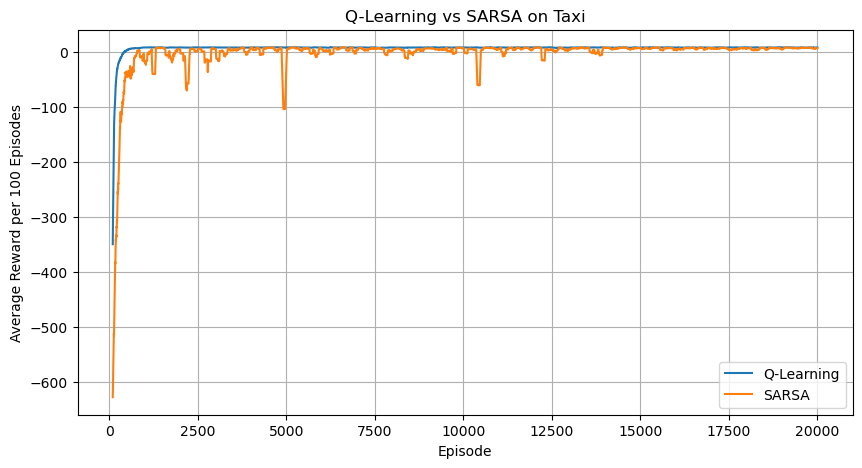

In [24]:
# Convert both reward lists to pandas Series.
q_learning_rewards_series = pd.Series(taxi_rewards)
sarsa_rewards_series = pd.Series(sarsa_rewards)

# Calculate rolling averages with a window size of 100 episodes.
q_learning_average_100 = q_learning_rewards_series.rolling(window=100).mean()
sarsa_average_100 = sarsa_rewards_series.rolling(window=100).mean()

# Plot both learning curves on the same figure.
plt.figure(figsize=(10, 5))
plt.plot(q_learning_average_100, label="Q-Learning")
plt.plot(sarsa_average_100, label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Average Reward per 100 Episodes")
plt.title("Q-Learning vs SARSA on Taxi")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Define a function to evaluate a trained agent.
def evaluate_agent(env_name, q_table, test_episodes=100):
    # Create a fresh environment for evaluation.
    env = gym.make(env_name)

    test_rewards = []
    successful_episodes = 0

    for episode in range(test_episodes):
        # Reset the environment at the beginning of each test episode.
        state, info = env.reset(seed=42)

        done = False
        total_reward = 0

        # Run the episode using pure exploitation.
        while not done:
            # Choose the best action from the learned Q-table.
            action = np.argmax(q_table[state])

            # Apply the action to the environment.
            next_state, reward, terminated, truncated, info = env.step(action)

            # Check whether the episode has ended.
            done = terminated or truncated

            # Update reward and state.
            total_reward += reward
            state = next_state

        # Store the total reward.
        test_rewards.append(total_reward)

        # Count success as an episode with positive total reward.
        if total_reward > 0:
            successful_episodes += 1

    # Calculate average reward and success rate.
    average_reward = np.mean(test_rewards)
    success_rate = successful_episodes / test_episodes

    return average_reward, success_rate

In [26]:
# Evaluate the Q-Learning agent from Task 3.
q_learning_avg_reward, q_learning_success_rate = evaluate_agent(
    "Taxi-v4",
    q_table_taxi,
    test_episodes=100
)

# Evaluate the SARSA agent.
sarsa_avg_reward, sarsa_success_rate = evaluate_agent(
    "Taxi-v4",
    q_table_sarsa,
    test_episodes=100
)

print("Q-Learning Evaluation:")
print("Average reward:", q_learning_avg_reward)
print("Success rate:", q_learning_success_rate)

print("\nSARSA Evaluation:")
print("Average reward:", sarsa_avg_reward)
print("Success rate:", sarsa_success_rate)

Q-Learning Evaluation:
Average reward: 8.0
Success rate: 1.0

SARSA Evaluation:
Average reward: 8.0
Success rate: 1.0


In [27]:
# Create a simple comparison table for the two algorithms.
comparison_results = pd.DataFrame({
    "Algorithm": ["Q-Learning", "SARSA"],
    "Average Reward": [q_learning_avg_reward, sarsa_avg_reward],
    "Success Rate": [q_learning_success_rate, sarsa_success_rate]
})

comparison_results

,Algorithm,Average Reward,Success Rate
0,Q-Learning,8.0,1.0
1,SARSA,8.0,1.0


## Task 4 Interpretation

In this task, SARSA was implemented and compared with Q-Learning on the Taxi environment. Both algorithms used the same environment with 500 states and 6 actions, and the SARSA Q-table was initialized with the shape `(500, 6)`.

The training plot shows that both algorithms improved from very negative rewards to stable positive rewards. Q-Learning improved more smoothly, while SARSA had a few larger drops during training. This is expected because SARSA learns using the actual next action chosen by the current epsilon-greedy policy, so exploration can affect its updates more directly.

In the final evaluation, both Q-Learning and SARSA achieved an average reward of 8.0 and a success rate of 1.0 over 100 test episodes. This means both trained agents successfully completed all test episodes using their learned policies.

The main difference between the algorithms is their update rule. Q-Learning is off-policy because it updates using the best possible next action, even if that action was not actually selected during training. SARSA is on-policy because it updates using the actual next action selected by the current policy. In this run, both algorithms reached the same final performance, but Q-Learning appeared slightly smoother during training. SARSA can still be useful in environments where it is important to account for exploratory or risky actions during learning.